### Instalação das devidas dependencias

In [17]:
import subprocess, sys

      # Execute esta célula uma única vez.
      # Após a instalação, reinicie o kernel (Kernel → Restart) antes de continuar.

packages = [
          # LLM / agentes
          "anthropic>=0.40.0",
          "langchain>=0.3.0",
          "langchain-anthropic>=0.3.0",
          "langchain-groq>=0.2.0",
          "langchain-ollama>=0.2.0",
          "langgraph>=0.2.0",
          "tenacity>=8.0.0",
          # dados / ML
          "pandas>=2.0.0",
          "scikit-learn>=1.3.0",
          "scipy>=1.11.0",
          "numpy>=1.26.0",
          # config / domínio
          "pydantic>=2.0.0",
          "pydantic-settings>=2.6.0",
          "python-dotenv>=1.0.0",
          # visualização / notebook
          "matplotlib>=3.8.0",
          "ipywidgets>=8.0.0",
          "jinja2>=3.1.0",
      ]

for pkg in packages:
          result = subprocess.run(
              [sys.executable, "-m", "pip", "install", "-q", pkg],
              capture_output=True, text=True,
          )
          status = "OK  " if result.returncode == 0 else "ERRO"
          print(f"[{status}] {pkg}")

print("\nDependências instaladas. Reinicie o kernel antes de continuar.")


[OK  ] anthropic>=0.40.0
[OK  ] langchain>=0.3.0
[OK  ] langchain-anthropic>=0.3.0
[OK  ] langchain-groq>=0.2.0
[OK  ] langchain-ollama>=0.2.0
[OK  ] langgraph>=0.2.0
[OK  ] tenacity>=8.0.0
[OK  ] pandas>=2.0.0
[OK  ] scikit-learn>=1.3.0
[OK  ] scipy>=1.11.0
[OK  ] numpy>=1.26.0
[OK  ] pydantic>=2.0.0
[OK  ] pydantic-settings>=2.6.0
[OK  ] python-dotenv>=1.0.0
[OK  ] matplotlib>=3.8.0
[OK  ] ipywidgets>=8.0.0
[OK  ] jinja2>=3.1.0

Dependências instaladas. Reinicie o kernel antes de continuar.


In [18]:
import sys
from pathlib import Path

_cwd = Path().resolve()
ROOT = _cwd if (_cwd / "pyproject.toml").exists() else _cwd.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Root: {ROOT}")


Root: D:\mas4re


In [19]:
import logging
logging.basicConfig(level=logging.WARNING)

import pandas as pd
from sklearn.metrics import (
          classification_report,
          f1_score,
          accuracy_score,
          confusion_matrix,
          ConfusionMatrixDisplay,
      )
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 110

### Configuração do Modelo

In [20]:
from config.settings import settings

      # Troque aqui para testar outros provedores:
      #   "ollama/qwen2.5:7b"        → Ollama local (padrão, gratuito)
      #   "claude-haiku-4-5"         → Anthropic (requer ANTHROPIC_API_KEY)
      #   "llama-3.3-70b-versatile"  → Groq (requer GROQ_API_KEY)
MODEL = settings.classifier_model

SAMPLE_N = 30
SEED = 42

print(f"Modelo : {MODEL}")
print(f"Amostra: {SAMPLE_N} requisitos (seed={SEED})")

Modelo : ollama/qwen2.5:7b
Amostra: 30 requisitos (seed=42)


## Carregando o Promise + 

In [21]:
from datasets.promise import PromiseAdapter

adapter = PromiseAdapter(path=ROOT / settings.promise_dataset_path)
sample = adapter.load_sample(n=SAMPLE_N, seed=SEED)

print(f"Requisitos carregados: {len(sample)}")

pd.DataFrame([
          {
              "id": r.id[:8],
              "texto": r.text[:70] + "...",
              "label": r.metadata["label_type"],
              "categoria": r.metadata["label_category"],
          }
          for r in sample[:8]
      ])

Requisitos carregados: 30


,id,texto,label,categoria
0,1283ea44,"visualizando os detalhes de um filme, o site e...",F,F
1,fb71aa37,A funcionalidade de lavagem de eletrodos terá ...,F,F
2,29e33ced,O usuário deverá localizar facilmente as instr...,NF,US
3,725968d3,O produto aumentará a produtividade dos Estima...,NF,US
4,7258b6bf,Se a pontuação do lead estiver dentro da média...,F,F
5,335dddb8,"Assim que o jogo for iniciado, o produto permi...",F,F
6,dec11ed2,Somente usuários com acesso à Atualização deve...,NF,SE
7,26428f8c,O tempo de resposta das tarefas gerais de gest...,NF,PE


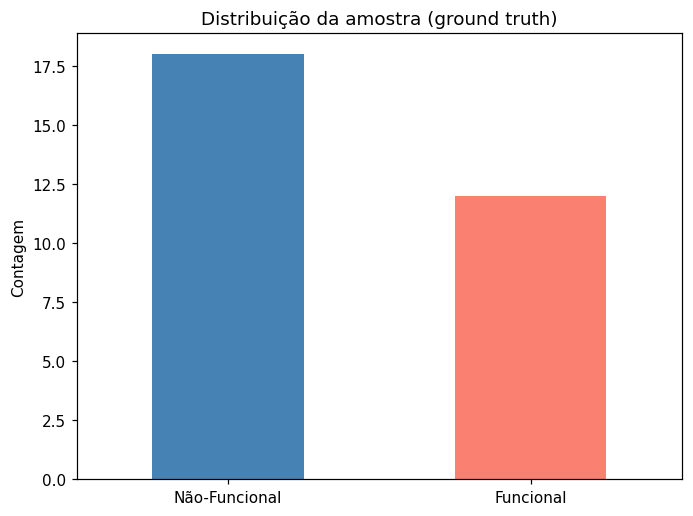

In [22]:
labels = [r.metadata["label_type"] for r in sample]
pd.Series(labels).value_counts().rename(
          index={"F": "Funcional", "NF": "Não-Funcional"}
      ).plot(kind="bar", title="Distribuição da amostra (ground truth)",
             color=["steelblue", "salmon"])
plt.ylabel("Contagem")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Executando o classification agent

In [23]:
from agents.classifier import ClassificationAgent
from domain.models import PipelineState

agent = ClassificationAgent(model=MODEL, temperature=0.0)
state = PipelineState(raw_requirements=sample)

print("Classificando...")
state = agent.run(state)
print(f"Concluído: {len(state.classified_requirements)} requisitos classificados")

Classificando...
Concluído: 30 requisitos classificados


In [24]:
print(f"{'#':<4} {'TIPO':<6} {'CAT':<5} {'CONF':<6} {'TEXTO'}")
print("-" * 80)
for i, r in enumerate(state.classified_requirements, 1):
    tipo  = r.requirement_type.value
    cat   = r.nfr_category.value if r.nfr_category else "-"
    conf  = f"{r.confidence:.2f}"
    texto = r.text[:55] + ("..." if len(r.text) > 55 else "")
    gold  = r.metadata["label_type"]
    marca = "✓" if gold == tipo else "✗"
    print(f"{i:<4} {tipo:<6} {cat:<5} {conf:<6} {marca}  {texto}")

#    TIPO   CAT   CONF   TEXTO
--------------------------------------------------------------------------------
1    F      -     0.95   ✓  visualizando os detalhes de um filme, o site exibirá a ...
2    F      -     0.95   ✓  A funcionalidade de lavagem de eletrodos terá uma inter...
3    NF     US    0.85   ✓  O usuário deverá localizar facilmente as instruções dur...
4    F      -     0.85   ✗  O produto aumentará a produtividade dos Estimadores de ...
5    F      -     0.85   ✓  Se a pontuação do lead estiver dentro da média média, e...
6    F      -     0.90   ✓  Assim que o jogo for iniciado, o produto permitirá que ...
7    F      -     1.00   ✗  Somente usuários com acesso à Atualização devem poder i...
8    NF     PE    0.90   ✓  O tempo de resposta das tarefas gerais de gestão de alu...
9    F      -     1.00   ✓  Para cada arremesso o produto deverá marcar o arremesso...
10   F      -     0.95   ✓  Os Administradores do Programa/Membros da Equipe de Enf...
11   F      -     

In [25]:
results = state.classified_requirements

df = pd.DataFrame([{
          "texto": r.text[:65] + "...",
          "gold": r.metadata["label_type"],
          "pred": r.requirement_type.value,
          "categoria_pred": r.nfr_category.value if r.nfr_category else "-",
          "confiança": round(r.confidence, 2),
          "correto": r.metadata["label_type"] == r.requirement_type.value,
      } for r in results])

def _highlight(val):
          if val is True:
              return "background-color: #d4edda"
          if val is False:
              return "background-color: #f8d7da"
          return ""

df.style.map(_highlight, subset=["correto"])

,texto,gold,pred,categoria_pred,confiança,correto
0,"visualizando os detalhes de um filme, o site exibirá a descrição ...",F,F,-,0.950000,True
1,A funcionalidade de lavagem de eletrodos terá uma interface na qu...,F,F,-,0.950000,True
2,O usuário deverá localizar facilmente as instruções durante a uti...,NF,NF,US,0.850000,True
3,O produto aumentará a produtividade dos Estimadores de Colisão. 8...,NF,F,-,0.850000,False
4,"Se a pontuação do lead estiver dentro da média média, ela será de...",F,F,-,0.850000,True
5,"Assim que o jogo for iniciado, o produto permitirá que cada jogad...",F,F,-,0.900000,True
6,Somente usuários com acesso à Atualização devem poder iniciar sol...,NF,F,-,1.000000,False
7,O tempo de resposta das tarefas gerais de gestão de alunos não de...,NF,NF,PE,0.900000,True
8,Para cada arremesso o produto deverá marcar o arremesso como um a...,F,F,-,1.000000,True
9,Os Administradores do Programa/Membros da Equipe de Enfermagem te...,F,F,-,0.950000,True


In [26]:
y_true = df["gold"].tolist()
y_pred = df["pred"].tolist()

acc   = accuracy_score(y_true, y_pred)
f1    = f1_score(y_true, y_pred, average="macro", zero_division=0)
f1_f  = f1_score(y_true, y_pred, pos_label="F",  average="binary", zero_division=0)
f1_nf = f1_score(y_true, y_pred, pos_label="NF", average="binary", zero_division=0)

print(f"Acurácia  : {acc:.4f}")
print(f"F1 Macro  : {f1:.4f}")
print(f"F1 (F)    : {f1_f:.4f}")
print(f"F1 (NF)   : {f1_nf:.4f}")
print()
print(classification_report(y_true, y_pred, zero_division=0))

Acurácia  : 0.8333
F1 Macro  : 0.8286
F1 (F)    : 0.8000
F1 (NF)   : 0.8571

              precision    recall  f1-score   support

           F       0.77      0.83      0.80        12
          NF       0.88      0.83      0.86        18

    accuracy                           0.83        30
   macro avg       0.83      0.83      0.83        30
weighted avg       0.84      0.83      0.83        30



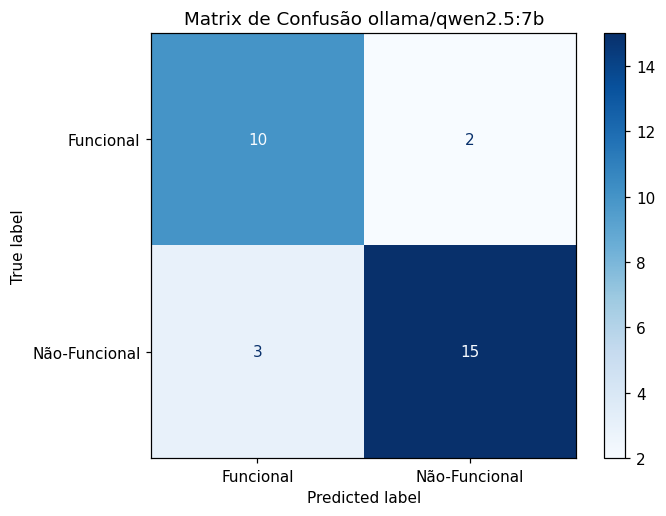

In [27]:
cm=confusion_matrix(y_true,y_pred,labels=["F","NF"])
disp= ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=["Funcional","Não-Funcional"])
disp.plot(cmap="Blues")
plt.title(f"Matrix de Confusão {MODEL}")
plt.tight_layout()
plt.show()

In [28]:
erros = df[df["correto"] == False][["texto", "gold", "pred", "confiança"]]
print(f"Total de erros: {len(erros)}")
erros

Total de erros: 5


,texto,gold,pred,confiança
3,O produto aumentará a produtividade dos Estima...,NF,F,0.85
6,Somente usuários com acesso à Atualização deve...,NF,F,1.00
15,Os membros da equipe devem ser capazes de conc...,NF,F,0.95
17,O Subsistema PME permitirá manter os submenus ...,F,NF,0.90
26,O estimador não deve aplicar peças recicladas ...,F,NF,0.85


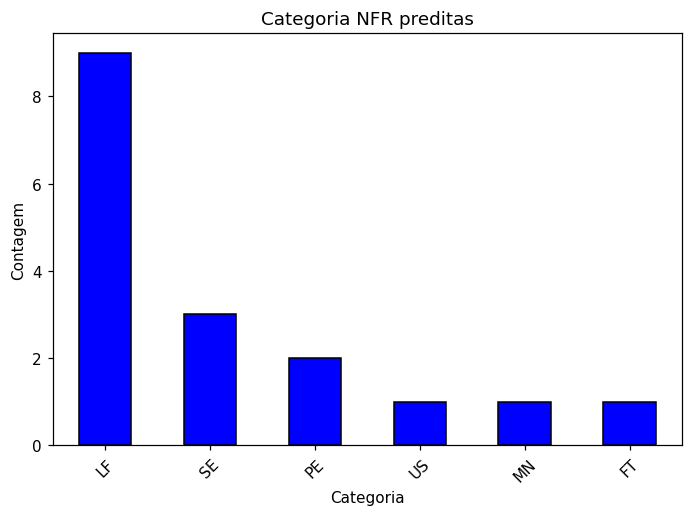

In [30]:
nf_results = df[df["pred"]=="NF"]

if nf_results.empty:
    print("Nenhuyum requisito classficado como NF na amostra")
else:
    nf_results["categoria_pred"].value_counts().plot(
        kind="bar",title="Categoria NFR preditas",
        color="blue",edgecolor="black"
    )
    plt.xlabel("Categoria")
    plt.ylabel("Contagem")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Rodando o experimento com o granite 4.1

In [ ]:
import sys
from pathlib import Path
ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print(f"Root: {ROOT}")

Root: D:\mas4re


In [3]:
import logging
logging.basicConfig(level=logging.WARNING)
import pandas as pd 
from sklearn.metrics import (
    classification_report,f1_score,accuracy_score,
    confusion_matrix,ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"]=110

In [4]:
from config.settings import settings

MODEL="ollama/granite4.1:3b"
SAMPLE_N=30
SEED=42

In [5]:
from datasets.promise import PromiseAdapter

adapter=PromiseAdapter(path=ROOT/settings.promise_dataset_path)
sample=adapter.load_sample(n=SAMPLE_N,seed=SEED)

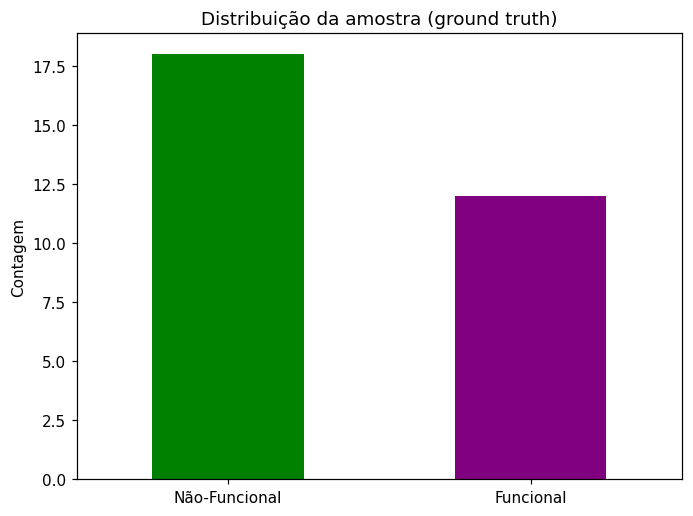

In [10]:
labels = [r.metadata["label_type"] for r in sample]
pd.Series(labels).value_counts().rename(
          index={"F": "Funcional", "NF": "Não-Funcional"}
      ).plot(kind="bar", title="Distribuição da amostra (ground truth)",
             color=["green", "purple"])
plt.ylabel("Contagem")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Executando o ClassificationAgent

In [ ]:
from agents.classifier import ClassificationAgent
from domain.models import PipelineState

agent = ClassificationAgent(model=MODEL, temperature=0.0)
state = PipelineState(raw_requirements=sample)
state = agent.run(state)

ERROR:agents.classifier:Parse falhou | req_id=bc0450f3 | erro=Expecting value: line 5 column 20 (char 94) | conteúdo='{\n  "requirement_type": "F",\n  "nfr_category": null,\n  "confidence": 0.95,\n  "justification": “O requisito descreve uma funcionalidade específica do software relacionada à exibição de detalhes de um f'
ERROR:agents.classifier:Parse falhou | req_id=40b02129 | erro=Expecting value: line 5 column 20 (char 94) | conteúdo='{\n  "requirement_type": "F",\n  "nfr_category": null,\n  "confidence": 0.95,\n  "justification": “O requisito descreve uma funcionalidade específica da aplicação, ou seja, a interface de lavagem de eletr'
ERROR:agents.classifier:Parse falhou | req_id=518b95d8 | erro=Expecting value: line 5 column 20 (char 93) | conteúdo='{\n  "requirement_type": "F",\n  "nfr_category": null,\n  "confidence": 0.9,\n  "justification": “O requisito descreve uma funcionalidade específica do software, ou seja, aumentar a produtividade dos Esti'
ERROR:agents.classifier:Pars

KeyboardInterrupt: 

ERROR:agents.classifier:Parse falhou | req_id=8704c50b | erro=Expecting value: line 5 column 20 (char 93) | conteúdo='{\n  "requirement_type": "F",\n  "nfr_category": null,\n  "confidence": 0.7,\n  "justification": “Este requisito descreve uma funcionalidade específica do sistema, ou seja, o uso de peças recicladas no pr'


In [ ]:
# Output linha a linha com ✓/✗
print(f"{'#':<4} {'TIPO':<6} {'CAT':<5} {'CONF':<6} {'TEXTO'}")
print("-" * 80)
for i, r in enumerate(state.classified_requirements, 1):
    ...
    print(f"{i:<4} {tipo:<6} {cat:<5} {conf:<6} {marca}  {texto}")